# k-Orthogonal Line Center: Complete Implementation, Experiments, and Validation

This notebook is the final experimental implementation for the MSc project. It contains:

1. the fixed-radius point version of Algorithm 1;
2. the equal-radius disk extension using the effective radius $R=r+\rho$;
3. exact brute-force baselines for small point and disk instances;
4. interactive interfaces and visualisation;
5. deterministic unit tests and randomised cross-validation;
6. reproducible instance generators;
7. approximation-quality and running-time experiments;
8. CSV, JSON, and figure export for dissertation reporting.

The implemented approximation routine is a **fixed-radius** routine. It does not search for the minimum possible radius. For a supplied radius, the output is evaluated using the line-count allowance of at most $2k$ and the requested geometric coverage condition.


## 1. Imports and reproducibility settings

The reported experiments use the self-contained Hopcroft-Karp/minimum-vertex-cover implementation. NetworkX remains available as an optional backend when it is installed, but it is not selected automatically. The interactive interfaces are enabled only when `ipywidgets` is available, so the core algorithms and experiments can run in an ordinary Python environment.


In [36]:
from collections import deque
from itertools import combinations
from pathlib import Path
import csv
import json
import math
import platform
import statistics
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

try:
    import networkx as nx
    from networkx.algorithms import bipartite
    NETWORKX_AVAILABLE = True
except ImportError:
    nx = None
    bipartite = None
    NETWORKX_AVAILABLE = False

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    widgets = None
    display = None
    clear_output = None
    WIDGETS_AVAILABLE = False

GLOBAL_SEED = 20260822
ATOL = 1e-8

print("NumPy version:", np.__version__)
print("NetworkX available:", NETWORKX_AVAILABLE)
print("Interactive widgets available:", WIDGETS_AVAILABLE)


NumPy version: 2.5.2
NetworkX available: False
Interactive widgets available: True


## 2. Input handling and geometric distance functions

For a point $p=(x,y)$, its distance to a vertical line $x=a$ is $|x-a|$, and its distance to a horizontal line $y=b$ is $|y-b|$.

For an equal-radius disk with centre $c$ and radius $\rho$, the distance to a line $\ell$ is

$$
d(D,\ell)=\max(0,d(c,\ell)-\rho).
$$

Consequently, $d(D,\ell)\le r$ if and only if $d(c,\ell)\le r+\rho$.


In [37]:
def as_point_array(values, name="points"):
    """Return a validated finite n x 2 floating-point array."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 2 or array.shape[1] != 2:
        raise ValueError(f"{name} must be an n x 2 array.")
    if len(array) == 0:
        raise ValueError(f"{name} must not be empty.")
    if not np.isfinite(array).all():
        raise ValueError(f"{name} must contain only finite values.")
    return array


def validate_positive_integer(value, name="k"):
    if isinstance(value, bool) or not isinstance(value, (int, np.integer)):
        raise ValueError(f"{name} must be a positive integer.")
    value = int(value)
    if value <= 0:
        raise ValueError(f"{name} must be a positive integer.")
    return value


def validate_radius(value, name="r", allow_zero=True):
    value = float(value)
    if not math.isfinite(value):
        raise ValueError(f"{name} must be finite.")
    if value < 0 or (not allow_zero and value == 0):
        relation = "non-negative" if allow_zero else "positive"
        raise ValueError(f"{name} must be {relation}.")
    return value


def parse_points(text):
    """Parse one 'x, y' or 'x y' pair per non-empty line; reject malformed lines."""
    points = []
    for line_number, raw_line in enumerate(text.splitlines(), start=1):
        stripped = raw_line.strip()
        if not stripped:
            continue
        fields = stripped.replace(",", " ").split()
        if len(fields) != 2:
            raise ValueError(
                f"Line {line_number} must contain exactly two coordinates: {raw_line!r}"
            )
        try:
            point = [float(fields[0]), float(fields[1])]
        except ValueError as exc:
            raise ValueError(f"Line {line_number} contains a non-numeric coordinate.") from exc
        if not np.isfinite(point).all():
            raise ValueError(f"Line {line_number} contains a non-finite coordinate.")
        points.append(point)
    return as_point_array(points, "points")


def centre_distances_to_selected_lines(points, selected_v_lines, selected_h_lines):
    """Distance from every centre/point to its nearest selected axis-parallel line."""
    points = as_point_array(points, "points")
    distances = np.full(len(points), np.inf, dtype=float)

    if len(selected_v_lines):
        vertical = np.asarray(selected_v_lines, dtype=float)
        distances = np.minimum(
            distances,
            np.min(np.abs(points[:, 0, None] - vertical[None, :]), axis=1),
        )

    if len(selected_h_lines):
        horizontal = np.asarray(selected_h_lines, dtype=float)
        distances = np.minimum(
            distances,
            np.min(np.abs(points[:, 1, None] - horizontal[None, :]), axis=1),
        )

    return distances


def disk_distances_to_selected_lines(centres, selected_v_lines, selected_h_lines, rho):
    """Distance from every equal-radius disk to its nearest selected line."""
    rho = validate_radius(rho, "rho", allow_zero=True)
    centre_distances = centre_distances_to_selected_lines(
        centres, selected_v_lines, selected_h_lines
    )
    return np.maximum(0.0, centre_distances - rho)


## 3. Sparse candidate-grid construction

The underlying grid has spacing $2r$ (or $2R$ for disks). A direct implementation that creates every grid line between the minimum and maximum coordinates can depend on the coordinate range rather than only on $n$.

The implementation below computes each object's nearest grid line arithmetically and retains only grid lines that are actually assigned at least one object. Therefore, each orientation has at most $n$ retained candidates, and the graph has $O(n)$ useful vertices and edges. To preserve the behaviour of the original `argmin` implementation, ties are resolved deterministically towards the candidate with the smaller lattice index.


In [38]:
def build_sparse_grid_assignments(points, coverage_radius):
    """Construct occupied candidates of a spacing-2R grid and direct assignments."""
    points = as_point_array(points, "points")
    coverage_radius = validate_radius(
        coverage_radius, "coverage_radius", allow_zero=False
    )

    step = 2.0 * coverage_radius
    x_origin = float(points[:, 0].min())
    y_origin = float(points[:, 1].max())

    x_scaled = (points[:, 0] - x_origin) / step
    y_scaled = (y_origin - points[:, 1]) / step

    # scaled values are non-negative. Subtracting a small tolerance before
    # floor(x + 0.5) resolves exact half-way ties towards the smaller lattice
    # index, matching np.argmin on the original ordered candidate arrays.
    vertical_lattice_ids = np.floor(x_scaled + 0.5 - 1e-12).astype(np.int64)
    horizontal_lattice_ids = np.floor(y_scaled + 0.5 - 1e-12).astype(np.int64)

    used_vertical_ids = np.unique(vertical_lattice_ids)
    used_horizontal_ids = np.unique(horizontal_lattice_ids)

    vertical_lines = x_origin + step * used_vertical_ids.astype(float)
    horizontal_lines = y_origin - step * used_horizontal_ids.astype(float)

    vertical_compact = {int(grid_id): i for i, grid_id in enumerate(used_vertical_ids)}
    horizontal_compact = {int(grid_id): i for i, grid_id in enumerate(used_horizontal_ids)}

    assignments = []
    for point_id, (point, v_grid, h_grid) in enumerate(
        zip(points, vertical_lattice_ids, horizontal_lattice_ids)
    ):
        v_index = vertical_compact[int(v_grid)]
        h_index = horizontal_compact[int(h_grid)]
        v_distance = abs(float(point[0]) - float(vertical_lines[v_index]))
        h_distance = abs(float(point[1]) - float(horizontal_lines[h_index]))
        assignments.append(
            {
                "point_id": point_id,
                "point": (float(point[0]), float(point[1])),
                "v_node": f"V{v_index}",
                "h_node": f"H{h_index}",
                "v_dist": v_distance,
                "h_dist": h_distance,
            }
        )

    max_assignment_distance = max(
        max(item["v_dist"], item["h_dist"]) for item in assignments
    )
    if max_assignment_distance > coverage_radius + ATOL:
        raise AssertionError("A point was assigned outside the grid coverage radius.")

    metadata = {
        "step": step,
        "x_origin": x_origin,
        "y_origin": y_origin,
        "vertical_lattice_ids": used_vertical_ids,
        "horizontal_lattice_ids": used_horizontal_ids,
        "max_assignment_distance": float(max_assignment_distance),
    }
    return vertical_lines, horizontal_lines, assignments, metadata


## 4. Bipartite graph and minimum vertex cover

Retained vertical candidates form one vertex class and retained horizontal candidates form the other. Every input object contributes an edge between its assigned vertical and horizontal candidate. Multiple objects can share one graph edge.

A maximum matching is computed with Hopcroft-Karp. Konig's theorem is then used to recover a minimum vertex cover. The selected cover vertices are converted back into line coordinates.


In [39]:
def build_bipartite_graph(assignments):
    """Build a compact graph representation; preserve all object IDs on duplicate edges."""
    vertical_nodes = sorted({item["v_node"] for item in assignments})
    horizontal_nodes = sorted({item["h_node"] for item in assignments})
    adjacency = {node: set() for node in vertical_nodes}
    edge_points = {}

    for item in assignments:
        edge = (item["v_node"], item["h_node"])
        adjacency[item["v_node"]].add(item["h_node"])
        edge_points.setdefault(edge, []).append(item["point_id"])

    return {
        "vertical_nodes": vertical_nodes,
        "horizontal_nodes": horizontal_nodes,
        "adjacency": {node: sorted(neighbours) for node, neighbours in adjacency.items()},
        "edges": sorted(edge_points),
        "edge_points": edge_points,
    }


def builtin_hopcroft_karp_minimum_vertex_cover(graph):
    """Self-contained Hopcroft-Karp matching and Konig minimum vertex cover."""
    left = list(graph["vertical_nodes"])
    right = list(graph["horizontal_nodes"])
    adjacency = graph["adjacency"]

    pair_left = {u: None for u in left}
    pair_right = {v: None for v in right}
    distance = {}
    infinity = float("inf")

    def bfs():
        queue = deque()
        augmenting_path_exists = False
        for u in left:
            if pair_left[u] is None:
                distance[u] = 0
                queue.append(u)
            else:
                distance[u] = infinity

        while queue:
            u = queue.popleft()
            for v in adjacency[u]:
                matched_u = pair_right[v]
                if matched_u is None:
                    augmenting_path_exists = True
                elif distance[matched_u] == infinity:
                    distance[matched_u] = distance[u] + 1
                    queue.append(matched_u)
        return augmenting_path_exists

    def dfs(u):
        for v in adjacency[u]:
            matched_u = pair_right[v]
            if matched_u is None or (
                distance.get(matched_u, infinity) == distance[u] + 1 and dfs(matched_u)
            ):
                pair_left[u] = v
                pair_right[v] = u
                return True
        distance[u] = infinity
        return False

    while bfs():
        for u in left:
            if pair_left[u] is None:
                dfs(u)

    # Alternating reachability from unmatched left vertices.
    reachable_left = {u for u in left if pair_left[u] is None}
    reachable_right = set()
    queue = deque(sorted(reachable_left))

    while queue:
        u = queue.popleft()
        for v in adjacency[u]:
            if pair_left[u] == v:  # traverse only unmatched edges from left to right
                continue
            if v not in reachable_right:
                reachable_right.add(v)
                matched_u = pair_right[v]
                if matched_u is not None and matched_u not in reachable_left:
                    reachable_left.add(matched_u)
                    queue.append(matched_u)

    cover = (set(left) - reachable_left) | reachable_right
    matching_size = sum(value is not None for value in pair_left.values())
    return cover, matching_size


def networkx_minimum_vertex_cover(graph):
    """NetworkX implementation used when the dependency is available."""
    if not NETWORKX_AVAILABLE:
        raise RuntimeError("NetworkX is not installed.")

    G = nx.Graph()
    G.add_nodes_from(graph["vertical_nodes"], bipartite=0)
    G.add_nodes_from(graph["horizontal_nodes"], bipartite=1)
    G.add_edges_from(graph["edges"])

    matching = bipartite.hopcroft_karp_matching(
        G, top_nodes=graph["vertical_nodes"]
    )
    cover = bipartite.to_vertex_cover(
        G, matching, top_nodes=graph["vertical_nodes"]
    )
    matching_size = sum(1 for node in graph["vertical_nodes"] if node in matching)
    return set(cover), matching_size


def minimum_vertex_cover_bipartite(graph, backend="builtin"):
    """Return a minimum vertex cover and the backend that produced it."""
    if backend not in {"auto", "networkx", "builtin"}:
        raise ValueError("backend must be 'auto', 'networkx', or 'builtin'.")

    resolved = "networkx" if backend == "auto" and NETWORKX_AVAILABLE else backend
    if resolved == "auto":
        resolved = "builtin"

    if resolved == "networkx":
        cover, matching_size = networkx_minimum_vertex_cover(graph)
    else:
        cover, matching_size = builtin_hopcroft_karp_minimum_vertex_cover(graph)

    cover_valid = all(u in cover or v in cover for u, v in graph["edges"])
    if not cover_valid:
        raise AssertionError("The returned vertex cover does not cover every graph edge.")
    if len(cover) != matching_size:
        raise AssertionError("Konig equality failed: cover size differs from matching size.")

    return cover, matching_size, resolved


## 5. Algorithm 1 for point inputs

For a supplied $r>0$, this routine constructs the sparse spacing-$2r$ grid, builds the bipartite graph, obtains a minimum vertex cover, and validates the selected lines geometrically. The status `WITHIN_2K` means that the output satisfies the bicriteria line allowance; it does **not** claim that a solution using at most $k$ lines has been found.


In [40]:
def two_factor_kolcr(points, k, r, matching_backend="builtin"):
    """Run the fixed-radius point version of Algorithm 1."""
    start = time.perf_counter()
    points = as_point_array(points, "points")
    k = validate_positive_integer(k)
    r = validate_radius(r, "r", allow_zero=False)

    vertical_lines, horizontal_lines, assignments, grid_meta = (
        build_sparse_grid_assignments(points, r)
    )
    graph = build_bipartite_graph(assignments)
    cover, matching_size, backend = minimum_vertex_cover_bipartite(
        graph, backend=matching_backend
    )

    selected_v_indices = sorted(
        int(node[1:]) for node in cover if node.startswith("V")
    )
    selected_h_indices = sorted(
        int(node[1:]) for node in cover if node.startswith("H")
    )
    selected_v_lines = [float(vertical_lines[i]) for i in selected_v_indices]
    selected_h_lines = [float(horizontal_lines[i]) for i in selected_h_indices]

    distances = centre_distances_to_selected_lines(
        points, selected_v_lines, selected_h_lines
    )
    selected_count = len(selected_v_lines) + len(selected_h_lines)
    guarantee_satisfied = selected_count <= 2 * k

    return {
        "object_type": "point",
        "status": "WITHIN_2K" if guarantee_satisfied else "EXCEEDS_2K",
        "points": points,
        "n": len(points),
        "k": k,
        "r": r,
        "vertical_lines": vertical_lines,
        "horizontal_lines": horizontal_lines,
        "selected_v_lines": selected_v_lines,
        "selected_h_lines": selected_h_lines,
        "selected_line_count": selected_count,
        "limit_2k": 2 * k,
        "guarantee_satisfied": guarantee_satisfied,
        "cover_is_valid": all(u in cover or v in cover for u, v in graph["edges"]),
        "max_distance_to_selected": float(np.max(distances)),
        "all_points_within_r": bool(np.all(distances <= r + ATOL)),
        "candidate_vertical_count": len(vertical_lines),
        "candidate_horizontal_count": len(horizontal_lines),
        "graph_node_count": len(graph["vertical_nodes"]) + len(graph["horizontal_nodes"]),
        "graph_edge_count": len(graph["edges"]),
        "matching_size": matching_size,
        "matching_backend": backend,
        "max_grid_assignment_distance": grid_meta["max_assignment_distance"],
        "runtime_seconds": time.perf_counter() - start,
    }


def print_point_result(result):
    print("Status:", result["status"])
    print("n, k, r:", result["n"], result["k"], result["r"])
    print("Selected lines:", result["selected_line_count"], "/", result["limit_2k"])
    print("Vertical x =", np.round(result["selected_v_lines"], 4).tolist())
    print("Horizontal y =", np.round(result["selected_h_lines"], 4).tolist())
    print("Graph cover valid:", result["cover_is_valid"])
    print("All points within r:", result["all_points_within_r"])
    print("Maximum realised distance:", round(result["max_distance_to_selected"], 8))
    print(
        "Candidates (V/H), graph (V/E):",
        (result["candidate_vertical_count"], result["candidate_horizontal_count"]),
        (result["graph_node_count"], result["graph_edge_count"]),
    )
    print("Matching backend:", result["matching_backend"])
    print("Runtime:", round(result["runtime_seconds"], 8), "seconds")


def plot_point_solution(result, show_candidates=True, save_path=None):
    points = result["points"]
    r = result["r"]
    fig, ax = plt.subplots(figsize=(8, 6))

    if show_candidates:
        for x in result["vertical_lines"]:
            ax.axvline(x, linestyle="--", linewidth=0.8, color="grey", alpha=0.35)
        for y in result["horizontal_lines"]:
            ax.axhline(y, linestyle="--", linewidth=0.8, color="grey", alpha=0.35)

    for x in result["selected_v_lines"]:
        ax.axvspan(x - r, x + r, color="tab:blue", alpha=0.10)
        ax.axvline(x, color="tab:blue", linewidth=2.5)
    for y in result["selected_h_lines"]:
        ax.axhspan(y - r, y + r, color="tab:orange", alpha=0.10)
        ax.axhline(y, color="tab:orange", linewidth=2.5)

    ax.scatter(points[:, 0], points[:, 1], s=42, color="black", label="Input points")
    for i, (x, y) in enumerate(points):
        ax.annotate(str(i), (x, y), xytext=(4, 4), textcoords="offset points", fontsize=8)

    margin = max(2 * r, 1.0)
    ax.set_xlim(points[:, 0].min() - margin, points[:, 0].max() + margin)
    ax.set_ylim(points[:, 1].min() - margin, points[:, 1].max() + margin)
    ax.set_xlabel("x-coordinate")
    ax.set_ylabel("y-coordinate")
    ax.set_title(
        f"Point Algorithm 1 | {result['status']} | "
        f"k={result['k']}, r={r:g}, selected={result['selected_line_count']}/{result['limit_2k']}"
    )
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, ax


## 6. Equal-radius disk extension

For disks of common radius $\rho$, the algorithm applies the point construction to the disk centres using

$$R=r+\rho.$$

The retained candidate grid therefore has spacing $2R$. Validation is performed using the actual disk-to-line distance, rather than only the centre distance.


In [41]:
def two_factor_disk_kolcr(disk_centres, k, r, disk_radius, matching_backend="builtin"):
    """Run the fixed-radius equal-disk extension of Algorithm 1."""
    start = time.perf_counter()
    centres = as_point_array(disk_centres, "disk_centres")
    k = validate_positive_integer(k)
    r = validate_radius(r, "r", allow_zero=True)
    rho = validate_radius(disk_radius, "disk_radius", allow_zero=True)
    effective_radius = r + rho
    if effective_radius <= 0:
        raise ValueError("R = r + disk_radius must be positive.")

    vertical_lines, horizontal_lines, assignments, grid_meta = (
        build_sparse_grid_assignments(centres, effective_radius)
    )
    graph = build_bipartite_graph(assignments)
    cover, matching_size, backend = minimum_vertex_cover_bipartite(
        graph, backend=matching_backend
    )

    selected_v_indices = sorted(
        int(node[1:]) for node in cover if node.startswith("V")
    )
    selected_h_indices = sorted(
        int(node[1:]) for node in cover if node.startswith("H")
    )
    selected_v_lines = [float(vertical_lines[i]) for i in selected_v_indices]
    selected_h_lines = [float(horizontal_lines[i]) for i in selected_h_indices]

    centre_distances = centre_distances_to_selected_lines(
        centres, selected_v_lines, selected_h_lines
    )
    disk_distances = np.maximum(0.0, centre_distances - rho)
    selected_count = len(selected_v_lines) + len(selected_h_lines)
    guarantee_satisfied = selected_count <= 2 * k

    return {
        "object_type": "disk",
        "status": "WITHIN_2K" if guarantee_satisfied else "EXCEEDS_2K",
        "disk_centres": centres,
        "n": len(centres),
        "k": k,
        "r": r,
        "disk_radius": rho,
        "effective_radius": effective_radius,
        "vertical_lines": vertical_lines,
        "horizontal_lines": horizontal_lines,
        "selected_v_lines": selected_v_lines,
        "selected_h_lines": selected_h_lines,
        "selected_line_count": selected_count,
        "limit_2k": 2 * k,
        "guarantee_satisfied": guarantee_satisfied,
        "cover_is_valid": all(u in cover or v in cover for u, v in graph["edges"]),
        "max_centre_distance_to_selected": float(np.max(centre_distances)),
        "max_disk_distance_to_selected": float(np.max(disk_distances)),
        "all_disks_within_r": bool(np.all(disk_distances <= r + ATOL)),
        "disk_reduction_equivalence": bool(
            np.array_equal(
                disk_distances <= r + ATOL,
                centre_distances <= effective_radius + ATOL,
            )
        ),
        "candidate_vertical_count": len(vertical_lines),
        "candidate_horizontal_count": len(horizontal_lines),
        "graph_node_count": len(graph["vertical_nodes"]) + len(graph["horizontal_nodes"]),
        "graph_edge_count": len(graph["edges"]),
        "matching_size": matching_size,
        "matching_backend": backend,
        "max_grid_assignment_distance": grid_meta["max_assignment_distance"],
        "runtime_seconds": time.perf_counter() - start,
    }


def print_disk_result(result):
    print("Status:", result["status"])
    print(
        "n, k, r, rho, R:",
        result["n"], result["k"], result["r"],
        result["disk_radius"], result["effective_radius"],
    )
    print("Selected lines:", result["selected_line_count"], "/", result["limit_2k"])
    print("Vertical x =", np.round(result["selected_v_lines"], 4).tolist())
    print("Horizontal y =", np.round(result["selected_h_lines"], 4).tolist())
    print("Graph cover valid:", result["cover_is_valid"])
    print("All disks within r:", result["all_disks_within_r"])
    print("R-reduction equivalence:", result["disk_reduction_equivalence"])
    print("Maximum disk distance:", round(result["max_disk_distance_to_selected"], 8))
    print("Runtime:", round(result["runtime_seconds"], 8), "seconds")


def plot_disk_solution(result, show_candidates=True, save_path=None):
    centres = result["disk_centres"]
    rho = result["disk_radius"]
    R = result["effective_radius"]
    fig, ax = plt.subplots(figsize=(8, 6))

    if show_candidates:
        for x in result["vertical_lines"]:
            ax.axvline(x, linestyle="--", linewidth=0.8, color="grey", alpha=0.35)
        for y in result["horizontal_lines"]:
            ax.axhline(y, linestyle="--", linewidth=0.8, color="grey", alpha=0.35)

    for x in result["selected_v_lines"]:
        ax.axvspan(x - R, x + R, color="tab:blue", alpha=0.10)
        ax.axvline(x, color="tab:blue", linewidth=2.5)
    for y in result["selected_h_lines"]:
        ax.axhspan(y - R, y + R, color="tab:orange", alpha=0.10)
        ax.axhline(y, color="tab:orange", linewidth=2.5)

    for i, (x, y) in enumerate(centres):
        ax.add_patch(Circle((x, y), rho, fill=False, linewidth=1.3, color="black"))
        ax.scatter(x, y, s=25, color="black")
        ax.annotate(str(i), (x, y), xytext=(4, 4), textcoords="offset points", fontsize=8)

    margin = max(2 * R, rho, 1.0)
    ax.set_xlim(centres[:, 0].min() - margin, centres[:, 0].max() + margin)
    ax.set_ylim(centres[:, 1].min() - margin, centres[:, 1].max() + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x-coordinate")
    ax.set_ylabel("y-coordinate")
    ax.set_title(
        f"Disk Algorithm 1 | {result['status']} | k={result['k']}, "
        f"r={result['r']:g}, rho={rho:g}, selected={result['selected_line_count']}/{result['limit_2k']}"
    )
    ax.grid(alpha=0.2)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, ax


## 7. Exact fixed-radius baselines for small instances

For one orientation, a point defines an interval of line coordinates that cover it. If a selected line covers a non-empty subset, it can be moved to an endpoint of the common intersection without losing that subset. Therefore an optimal fixed-radius solution exists among coordinates $x_i\pm r$ and $y_i\pm r$ (or $x_i\pm R$ and $y_i\pm R$ for disks).

The solver below enumerates subsets of those candidates in increasing cardinality. It is exact for the stated fixed-radius axis-parallel problem, but its running time is combinatorial, so it is deliberately restricted to small instances.


In [42]:
def build_exact_candidate_lines(points, coverage_radius):
    """Endpoint candidates sufficient for an exact fixed-radius solution."""
    points = as_point_array(points, "points")
    coverage_radius = validate_radius(
        coverage_radius, "coverage_radius", allow_zero=True
    )
    x_candidates = np.concatenate(
        (points[:, 0] - coverage_radius, points[:, 0] + coverage_radius)
    )
    y_candidates = np.concatenate(
        (points[:, 1] - coverage_radius, points[:, 1] + coverage_radius)
    )
    vertical = np.unique(np.round(x_candidates, 12))
    horizontal = np.unique(np.round(y_candidates, 12))
    return vertical, horizontal


def coverage_mask(points, orientation, coordinate, coverage_radius):
    points = as_point_array(points, "points")
    if orientation == "V":
        covered = np.abs(points[:, 0] - coordinate) <= coverage_radius + ATOL
    elif orientation == "H":
        covered = np.abs(points[:, 1] - coordinate) <= coverage_radius + ATOL
    else:
        raise ValueError("orientation must be 'V' or 'H'.")

    mask = 0
    for index, is_covered in enumerate(covered):
        if is_covered:
            mask |= 1 << index
    return mask


def build_exact_candidates(points, coverage_radius):
    """Build candidates and remove candidates having identical coverage masks."""
    vertical, horizontal = build_exact_candidate_lines(points, coverage_radius)
    candidates = []
    seen_masks = set()

    for orientation, coordinates in (("V", vertical), ("H", horizontal)):
        for coordinate in coordinates:
            mask = coverage_mask(points, orientation, float(coordinate), coverage_radius)
            if mask and mask not in seen_masks:
                seen_masks.add(mask)
                candidates.append((orientation, float(coordinate), mask))
    return candidates, vertical, horizontal


def brute_force_minimum_lines(points, max_lines, coverage_radius):
    """Exact minimum-cardinality cover up to max_lines; intended for small inputs."""
    start = time.perf_counter()
    points = as_point_array(points, "points")
    max_lines = validate_positive_integer(max_lines, "max_lines")
    coverage_radius = validate_radius(
        coverage_radius, "coverage_radius", allow_zero=True
    )

    candidates, vertical, horizontal = build_exact_candidates(points, coverage_radius)
    full_mask = (1 << len(points)) - 1
    best_solution = None
    combinations_checked = 0

    for size in range(1, min(max_lines, len(candidates)) + 1):
        for candidate_subset in combinations(candidates, size):
            combinations_checked += 1
            union_mask = 0
            for _, _, mask in candidate_subset:
                union_mask |= mask
                if union_mask == full_mask:
                    break
            if union_mask == full_mask:
                best_solution = candidate_subset
                break
        if best_solution is not None:
            break

    selected_v_lines = [] if best_solution is None else [
        coordinate for orientation, coordinate, _ in best_solution if orientation == "V"
    ]
    selected_h_lines = [] if best_solution is None else [
        coordinate for orientation, coordinate, _ in best_solution if orientation == "H"
    ]
    distances = centre_distances_to_selected_lines(
        points, selected_v_lines, selected_h_lines
    )
    possible = best_solution is not None

    return {
        "status": "POSSIBLE_WITHIN_K" if possible else "NOT_POSSIBLE_WITHIN_K",
        "possible": possible,
        "points": points,
        "n": len(points),
        "k": max_lines,
        "coverage_radius": coverage_radius,
        "vertical_lines": vertical,
        "horizontal_lines": horizontal,
        "selected_v_lines": selected_v_lines,
        "selected_h_lines": selected_h_lines,
        "selected_line_count": len(selected_v_lines) + len(selected_h_lines),
        "max_distance_to_selected": float(np.max(distances)),
        "all_centres_within_radius": bool(
            possible and np.all(distances <= coverage_radius + ATOL)
        ),
        "num_raw_endpoint_lines": len(vertical) + len(horizontal),
        "num_distinct_coverage_candidates": len(candidates),
        "combinations_checked": combinations_checked,
        "runtime_seconds": time.perf_counter() - start,
    }


def brute_force_optimal_kolcr(points, k, r):
    r = validate_radius(r, "r", allow_zero=True)
    result = brute_force_minimum_lines(points, k, r)
    result.update(
        {
            "object_type": "point",
            "r": r,
            "all_points_within_r": result["all_centres_within_radius"],
        }
    )
    return result


def brute_force_optimal_disk_kolcr(disk_centres, k, r, disk_radius):
    centres = as_point_array(disk_centres, "disk_centres")
    r = validate_radius(r, "r", allow_zero=True)
    rho = validate_radius(disk_radius, "disk_radius", allow_zero=True)
    effective_radius = r + rho
    result = brute_force_minimum_lines(centres, k, effective_radius)
    disk_distances = disk_distances_to_selected_lines(
        centres,
        result["selected_v_lines"],
        result["selected_h_lines"],
        rho,
    )
    result.update(
        {
            "object_type": "disk",
            "disk_centres": centres,
            "r": r,
            "disk_radius": rho,
            "effective_radius": effective_radius,
            "max_disk_distance_to_selected": float(np.max(disk_distances)),
            "all_disks_within_r": bool(
                result["possible"] and np.all(disk_distances <= r + ATOL)
            ),
        }
    )
    return result


def print_exact_result(result):
    print("Status:", result["status"])
    print("n, k:", result["n"], result["k"])
    print("Optimal selected lines:", result["selected_line_count"])
    print("Vertical x =", np.round(result["selected_v_lines"], 4).tolist())
    print("Horizontal y =", np.round(result["selected_h_lines"], 4).tolist())
    print("Distinct coverage candidates:", result["num_distinct_coverage_candidates"])
    print("Combinations checked:", result["combinations_checked"])
    print("Runtime:", round(result["runtime_seconds"], 8), "seconds")


def compare_point_algorithms(points, k, r, matching_backend="builtin", verbose=True):
    approximation = two_factor_kolcr(points, k, r, matching_backend)
    exact = brute_force_optimal_kolcr(points, k, r)
    ratio = (
        approximation["selected_line_count"] / exact["selected_line_count"]
        if exact["possible"] else math.nan
    )
    if verbose:
        print("Algorithm 1")
        print_point_result(approximation)
        print("\nExact baseline")
        print_exact_result(exact)
        print("Line-count ratio:", None if math.isnan(ratio) else round(ratio, 4))
    return approximation, exact, ratio


def compare_disk_algorithms(centres, k, r, rho, matching_backend="builtin", verbose=True):
    approximation = two_factor_disk_kolcr(centres, k, r, rho, matching_backend)
    exact = brute_force_optimal_disk_kolcr(centres, k, r, rho)
    ratio = (
        approximation["selected_line_count"] / exact["selected_line_count"]
        if exact["possible"] else math.nan
    )
    if verbose:
        print("Disk Algorithm 1")
        print_disk_result(approximation)
        print("\nExact disk baseline")
        print_exact_result(exact)
        print("Line-count ratio:", None if math.isnan(ratio) else round(ratio, 4))
    return approximation, exact, ratio


## 8. Interactive interfaces

These interfaces call the same tested algorithm functions used by the batch experiments. Malformed input is rejected explicitly rather than silently ignored.


In [43]:
def _require_widgets():
    if not WIDGETS_AVAILABLE:
        raise RuntimeError(
            "ipywidgets and IPython are required for the interactive interface. "
            "The algorithms and experiments can still be called directly."
        )


def show_point_interface(default_text="1,2\n2,5\n4,3\n6,7\n8,1", default_k=2, default_r=2.0):
    _require_widgets()
    points_box = widgets.Textarea(
        value=default_text,
        description="Points:",
        layout=widgets.Layout(width="500px", height="150px"),
    )
    k_box = widgets.IntText(value=default_k, description="k:")
    r_box = widgets.FloatText(value=default_r, description="r:")
    button = widgets.Button(description="Run point Algorithm 1", button_style="success")
    output = widgets.Output()

    def run(_):
        with output:
            clear_output(wait=True)
            try:
                result = two_factor_kolcr(parse_points(points_box.value), k_box.value, r_box.value)
                print_point_result(result)
                plot_point_solution(result)
                plt.show()
            except Exception as exc:
                print("Error:", exc)

    button.on_click(run)
    display(points_box, widgets.HBox([k_box, r_box]), button, output)


def show_disk_interface(default_text="1,2\n2,5\n4,3\n6,7\n8,1", default_k=2,
                        default_r=1.0, default_rho=0.8):
    _require_widgets()
    centres_box = widgets.Textarea(
        value=default_text,
        description="Centres:",
        layout=widgets.Layout(width="500px", height="150px"),
    )
    k_box = widgets.IntText(value=default_k, description="k:")
    r_box = widgets.FloatText(value=default_r, description="r:")
    rho_box = widgets.FloatText(value=default_rho, description="rho:")
    button = widgets.Button(description="Run disk Algorithm 1", button_style="success")
    output = widgets.Output()

    def run(_):
        with output:
            clear_output(wait=True)
            try:
                result = two_factor_disk_kolcr(
                    parse_points(centres_box.value), k_box.value, r_box.value, rho_box.value
                )
                print_disk_result(result)
                plot_disk_solution(result)
                plt.show()
            except Exception as exc:
                print("Error:", exc)

    button.on_click(run)
    display(centres_box, widgets.HBox([k_box, r_box, rho_box]), button, output)


def show_point_comparison_interface(default_text="1,2\n2,5\n4,3\n6,7\n8,1",
                                    default_k=2, default_r=2.0):
    _require_widgets()
    points_box = widgets.Textarea(
        value=default_text, description="Points:",
        layout=widgets.Layout(width="500px", height="150px")
    )
    k_box = widgets.IntText(value=default_k, description="k:")
    r_box = widgets.FloatText(value=default_r, description="r:")
    button = widgets.Button(description="Compare point methods", button_style="warning")
    output = widgets.Output()

    def run(_):
        with output:
            clear_output(wait=True)
            try:
                approximation, exact, _ = compare_point_algorithms(
                    parse_points(points_box.value), k_box.value, r_box.value
                )
                plot_point_solution(approximation)
                plt.show()
                if exact["possible"]:
                    exact_plot_result = {
                        **approximation,
                        "status": exact["status"],
                        "selected_v_lines": exact["selected_v_lines"],
                        "selected_h_lines": exact["selected_h_lines"],
                        "selected_line_count": exact["selected_line_count"],
                        "limit_2k": exact["k"],
                    }
                    plot_point_solution(exact_plot_result, show_candidates=False)
                    plt.show()
            except Exception as exc:
                print("Error:", exc)

    button.on_click(run)
    display(points_box, widgets.HBox([k_box, r_box]), button, output)


def show_disk_comparison_interface(default_text="1,2\n2,5\n4,3\n6,7\n8,1",
                                   default_k=2, default_r=1.0, default_rho=0.8):
    _require_widgets()
    centres_box = widgets.Textarea(
        value=default_text, description="Centres:",
        layout=widgets.Layout(width="500px", height="150px")
    )
    k_box = widgets.IntText(value=default_k, description="k:")
    r_box = widgets.FloatText(value=default_r, description="r:")
    rho_box = widgets.FloatText(value=default_rho, description="rho:")
    button = widgets.Button(description="Compare disk methods", button_style="warning")
    output = widgets.Output()

    def run(_):
        with output:
            clear_output(wait=True)
            try:
                approximation, exact, _ = compare_disk_algorithms(
                    parse_points(centres_box.value), k_box.value,
                    r_box.value, rho_box.value
                )
                plot_disk_solution(approximation)
                plt.show()
                if exact["possible"]:
                    exact_plot_result = {
                        **approximation,
                        "status": exact["status"],
                        "selected_v_lines": exact["selected_v_lines"],
                        "selected_h_lines": exact["selected_h_lines"],
                        "selected_line_count": exact["selected_line_count"],
                        "limit_2k": exact["k"],
                    }
                    plot_disk_solution(exact_plot_result, show_candidates=False)
                    plt.show()
            except Exception as exc:
                print("Error:", exc)

    button.on_click(run)
    display(
        centres_box, widgets.HBox([k_box, r_box, rho_box]), button, output
    )


# Uncomment one line in Jupyter to open an interface:
# show_point_interface()
# show_disk_interface()
# show_point_comparison_interface()
# show_disk_comparison_interface()


## 9. Reproducible instance generators

The generators cover several spatial structures rather than relying only on favourable uniform samples. `generate_k_coverable_points` creates instances with a known feasible cover of at most $k$ lines, which is useful for testing the theoretical $2k$ implication. Every generator accepts an explicit random seed.


In [44]:
def generate_points(n, distribution="uniform", seed=GLOBAL_SEED, scale=20.0):
    n = validate_positive_integer(n, "n")
    scale = validate_radius(scale, "scale", allow_zero=False)
    rng = np.random.default_rng(seed)

    if distribution == "uniform":
        points = rng.uniform(0.0, scale, size=(n, 2))
    elif distribution == "clustered":
        cluster_count = min(3, n)
        centres = rng.uniform(0.15 * scale, 0.85 * scale, size=(cluster_count, 2))
        labels = rng.integers(0, cluster_count, size=n)
        points = centres[labels] + rng.normal(0.0, 0.06 * scale, size=(n, 2))
        points = np.clip(points, 0.0, scale)
    elif distribution == "near_horizontal":
        band_count = min(3, n)
        bands = rng.uniform(0.15 * scale, 0.85 * scale, size=band_count)
        labels = rng.integers(0, band_count, size=n)
        x_values = rng.uniform(0.0, scale, size=n)
        y_values = bands[labels] + rng.normal(0.0, 0.01 * scale, size=n)
        points = np.column_stack((x_values, np.clip(y_values, 0.0, scale)))
    elif distribution == "repeated":
        base_count = max(1, min(n, n // 4))
        base = rng.uniform(0.0, scale, size=(base_count, 2))
        points = base[rng.integers(0, base_count, size=n)]
    elif distribution == "grid":
        side = int(math.ceil(math.sqrt(n)))
        coordinates = np.linspace(0.0, scale, side)
        mesh = np.array([(x, y) for x in coordinates for y in coordinates], dtype=float)
        points = mesh[:n]
    else:
        raise ValueError(
            "distribution must be uniform, clustered, near_horizontal, repeated, or grid."
        )
    return np.asarray(points, dtype=float)


def generate_k_coverable_points(n, k, coverage_radius, seed=GLOBAL_SEED, scale=20.0):
    """Generate an instance guaranteed coverable by the returned hidden k lines."""
    n = validate_positive_integer(n, "n")
    k = validate_positive_integer(k)
    coverage_radius = validate_radius(
        coverage_radius, "coverage_radius", allow_zero=False
    )
    scale = validate_radius(scale, "scale", allow_zero=False)
    rng = np.random.default_rng(seed)

    orientations = rng.choice(np.array(["V", "H"]), size=k)
    coordinates = rng.uniform(0.1 * scale, 0.9 * scale, size=k)
    hidden_lines = list(zip(orientations.tolist(), coordinates.tolist()))
    assigned_lines = np.arange(n) % k
    rng.shuffle(assigned_lines)

    points = np.empty((n, 2), dtype=float)
    for index, hidden_index in enumerate(assigned_lines):
        orientation, coordinate = hidden_lines[int(hidden_index)]
        perpendicular_offset = rng.uniform(-0.9 * coverage_radius, 0.9 * coverage_radius)
        if orientation == "V":
            points[index] = [coordinate + perpendicular_offset, rng.uniform(0.0, scale)]
        else:
            points[index] = [rng.uniform(0.0, scale), coordinate + perpendicular_offset]
    return points, hidden_lines


def make_edge_case_instances(r=2.0):
    r = validate_radius(r, "r", allow_zero=False)
    return {
        "single": np.array([[3.0, 4.0]]),
        "repeated": np.array([[2.0, 2.0]] * 5),
        "shared_vertical": np.array([[1.0, 0.0], [1.0, 5.0], [1.0, 10.0]]),
        "shared_horizontal": np.array([[0.0, 1.0], [5.0, 1.0], [10.0, 1.0]]),
        "tie_and_boundary": np.array([[0.0, 0.0], [r, r], [2.0 * r, 2.0 * r]]),
        "mixed_axes": np.array([[0.0, 0.0], [0.0, 8.0], [8.0, 4.0], [12.0, 4.0]]),
        "large_coordinate_gap": np.array([[0.0, 0.0], [1.0e9, 1.0e9]]),
    }


## 10. Result validators and deterministic tests

The validators recompute geometric distances independently from the reported Boolean fields. Tests cover graph optimality on small random graphs, point and disk coverage, exact feasible and infeasible cases, repeated coordinates, large coordinate gaps, malformed input, and the disk reduction.


In [45]:
def _validation_report(checks, context, raise_on_error=True):
    failed = [name for name, passed in checks.items() if not bool(passed)]
    report = {"context": context, "passed": not failed, "checks": checks, "failed": failed}
    if failed and raise_on_error:
        raise AssertionError(f"{context} failed checks: {failed}")
    return report


def validate_point_result(result, raise_on_error=True):
    recomputed = centre_distances_to_selected_lines(
        result["points"], result["selected_v_lines"], result["selected_h_lines"]
    )
    expected_count = len(result["selected_v_lines"]) + len(result["selected_h_lines"])
    checks = {
        "line_count_consistent": result["selected_line_count"] == expected_count,
        "cover_valid": result["cover_is_valid"],
        "geometric_coverage": bool(np.all(recomputed <= result["r"] + ATOL)),
        "max_distance_consistent": np.isclose(
            np.max(recomputed), result["max_distance_to_selected"], atol=ATOL
        ),
        "candidate_vertical_bound": result["candidate_vertical_count"] <= result["n"],
        "candidate_horizontal_bound": result["candidate_horizontal_count"] <= result["n"],
        "graph_edge_bound": result["graph_edge_count"] <= result["n"],
        "konig_equality": result["selected_line_count"] == result["matching_size"],
        "status_consistent": (
            result["status"] == "WITHIN_2K"
        ) == (result["selected_line_count"] <= result["limit_2k"]),
    }
    return _validation_report(checks, "point Algorithm 1", raise_on_error)


def validate_disk_result(result, raise_on_error=True):
    centre_distances = centre_distances_to_selected_lines(
        result["disk_centres"], result["selected_v_lines"], result["selected_h_lines"]
    )
    disk_distances = np.maximum(0.0, centre_distances - result["disk_radius"])
    expected_count = len(result["selected_v_lines"]) + len(result["selected_h_lines"])
    checks = {
        "line_count_consistent": result["selected_line_count"] == expected_count,
        "cover_valid": result["cover_is_valid"],
        "disk_coverage": bool(np.all(disk_distances <= result["r"] + ATOL)),
        "max_disk_distance_consistent": np.isclose(
            np.max(disk_distances), result["max_disk_distance_to_selected"], atol=ATOL
        ),
        "effective_radius_consistent": np.isclose(
            result["effective_radius"], result["r"] + result["disk_radius"], atol=ATOL
        ),
        "reduction_equivalence": np.array_equal(
            disk_distances <= result["r"] + ATOL,
            centre_distances <= result["effective_radius"] + ATOL,
        ),
        "candidate_vertical_bound": result["candidate_vertical_count"] <= result["n"],
        "candidate_horizontal_bound": result["candidate_horizontal_count"] <= result["n"],
        "graph_edge_bound": result["graph_edge_count"] <= result["n"],
        "konig_equality": result["selected_line_count"] == result["matching_size"],
        "status_consistent": (
            result["status"] == "WITHIN_2K"
        ) == (result["selected_line_count"] <= result["limit_2k"]),
    }
    return _validation_report(checks, "disk Algorithm 1", raise_on_error)


def validate_exact_result(result, disk=False, raise_on_error=True):
    possible = result["possible"]
    if disk:
        coverage_ok = result["all_disks_within_r"] if possible else True
    else:
        coverage_ok = result["all_points_within_r"] if possible else True
    checks = {
        "status_consistent": (
            result["status"] == "POSSIBLE_WITHIN_K"
        ) == possible,
        "budget_respected_if_possible": (
            result["selected_line_count"] <= result["k"] if possible else True
        ),
        "coverage_if_possible": coverage_ok,
        "nonempty_solution_if_possible": result["selected_line_count"] >= 1 if possible else True,
        "empty_solution_if_infeasible": result["selected_line_count"] == 0 if not possible else True,
    }
    return _validation_report(checks, "exact disk" if disk else "exact point", raise_on_error)


def _brute_graph_vertex_cover_size(graph):
    nodes = graph["vertical_nodes"] + graph["horizontal_nodes"]
    for size in range(len(nodes) + 1):
        for subset in combinations(nodes, size):
            chosen = set(subset)
            if all(u in chosen or v in chosen for u, v in graph["edges"]):
                return size
    raise AssertionError("No vertex cover found.")


def run_unit_tests(verbose=True):
    tests = []

    def record(name, function):
        start = time.perf_counter()
        try:
            function()
            tests.append({"test": name, "passed": True, "error": "",
                          "runtime_seconds": time.perf_counter() - start})
        except Exception as exc:
            tests.append({"test": name, "passed": False, "error": repr(exc),
                          "runtime_seconds": time.perf_counter() - start})

    sample = np.array([
        [1, 2], [2, 5], [4, 3], [6, 7], [8, 1],
        [10, 4], [12, 8], [15, 3], [16, 9], [10, 19]
    ], dtype=float)

    record("point sample validation", lambda: validate_point_result(two_factor_kolcr(sample, 3, 2.0)))
    record("disk sample validation", lambda: validate_disk_result(two_factor_disk_kolcr(sample, 3, 1.0, 0.8)))

    def large_gap_test():
        result = two_factor_kolcr(np.array([[0.0, 0.0], [1.0e9, 1.0e9]]), 1, 1.0)
        assert result["candidate_vertical_count"] <= 2
        assert result["candidate_horizontal_count"] <= 2
        validate_point_result(result)
    record("sparse grid with large coordinate gap", large_gap_test)

    def repeated_test():
        points = np.array([[2.0, 2.0]] * 6)
        approximation, exact, ratio = compare_point_algorithms(points, 1, 0.5, verbose=False)
        validate_point_result(approximation)
        validate_exact_result(exact)
        assert exact["selected_line_count"] == 1
        assert ratio == 1.0
    record("repeated coordinates", repeated_test)

    def exact_feasible_test():
        points = np.array([[0.0, 0.0], [0.0, 5.0], [0.0, 10.0]])
        result = brute_force_optimal_kolcr(points, 1, 0.0)
        validate_exact_result(result)
        assert result["possible"] and result["selected_line_count"] == 1
    record("exact point feasible case", exact_feasible_test)

    def exact_infeasible_test():
        points = np.array([[0.0, 0.0], [10.0, 10.0]])
        result = brute_force_optimal_kolcr(points, 1, 1.0)
        validate_exact_result(result)
        assert not result["possible"]
    record("exact point infeasible budget", exact_infeasible_test)

    def disk_zero_r_test():
        centres = np.array([[0.0, 0.0], [0.0, 5.0]])
        approximation = two_factor_disk_kolcr(centres, 1, 0.0, 1.0)
        exact = brute_force_optimal_disk_kolcr(centres, 1, 0.0, 1.0)
        validate_disk_result(approximation)
        validate_exact_result(exact, disk=True)
        assert exact["possible"]
    record("disk reduction with r equals zero", disk_zero_r_test)

    def malformed_parser_test():
        try:
            parse_points("1,2\nnot-a-point")
        except ValueError:
            return
        raise AssertionError("Malformed input was not rejected.")
    record("malformed text input rejected", malformed_parser_test)

    def invalid_parameter_test():
        failures = 0
        for call in (
            lambda: two_factor_kolcr([[0, 0]], 0, 1.0),
            lambda: two_factor_kolcr([[0, 0]], 1, 0.0),
            lambda: two_factor_disk_kolcr([[0, 0]], 1, -1.0, 1.0),
            lambda: two_factor_disk_kolcr([[0, 0]], 1, 0.0, 0.0),
        ):
            try:
                call()
            except ValueError:
                failures += 1
        assert failures == 4
    record("invalid parameters rejected", invalid_parameter_test)

    def graph_optimality_test():
        rng = np.random.default_rng(GLOBAL_SEED)
        for _ in range(30):
            left = [f"V{i}" for i in range(4)]
            right = [f"H{j}" for j in range(4)]
            edges = [(u, v) for u in left for v in right if rng.random() < 0.35]
            if not edges:
                edges = [(left[0], right[0])]
            graph = {
                "vertical_nodes": left,
                "horizontal_nodes": right,
                "adjacency": {u: sorted(v for x, v in edges if x == u) for u in left},
                "edges": sorted(set(edges)),
                "edge_points": {},
            }
            cover, matching_size = builtin_hopcroft_karp_minimum_vertex_cover(graph)
            assert all(u in cover or v in cover for u, v in graph["edges"])
            assert len(cover) == matching_size == _brute_graph_vertex_cover_size(graph)
    record("builtin matching and cover optimality", graph_optimality_test)

    failed = [test for test in tests if not test["passed"]]
    if verbose:
        for test in tests:
            marker = "PASS" if test["passed"] else "FAIL"
            print(f"[{marker}] {test['test']}")
            if test["error"]:
                print("       ", test["error"])
        print(f"Unit tests passed: {len(tests) - len(failed)}/{len(tests)}")
    if failed:
        raise AssertionError(f"{len(failed)} unit test(s) failed.")
    return tests


## 11. Randomised cross-validation against the exact baseline

For small instances, the approximate and exact routines are run on identical inputs. The main implication checked is:

> if the exact solver finds a solution using at most $k$ lines, Algorithm 1 must cover all objects and return at most $2k$ lines.

The experiment also checks the stronger observed ratio against the exact minimum. A failure raises an exception and records the seed needed to reproduce the instance.


In [46]:
def run_randomised_cross_validation(
    trials=30, max_n=8, seed=GLOBAL_SEED, raise_on_failure=True
):
    trials = validate_positive_integer(trials, "trials")
    max_n = validate_positive_integer(max_n, "max_n")
    if max_n < 2:
        raise ValueError("max_n must be at least 2.")

    rng = np.random.default_rng(seed)
    distributions = ["uniform", "clustered", "near_horizontal", "repeated", "grid"]
    records = []

    for trial in range(trials):
        n = int(rng.integers(2, max_n + 1))
        k = int(rng.integers(1, min(3, n) + 1))
        r = float(rng.uniform(0.4, 2.5))
        rho = float(rng.uniform(0.1, 1.2))
        distribution = distributions[int(rng.integers(0, len(distributions)))]
        instance_seed = int(rng.integers(0, 2**31 - 1))
        points = generate_points(n, distribution, instance_seed, scale=12.0)

        for object_type in ("point", "disk"):
            if object_type == "point":
                approximation = two_factor_kolcr(points, k, r)
                exact = brute_force_optimal_kolcr(points, k, r)
                validation = validate_point_result(approximation, raise_on_error=False)
                exact_validation = validate_exact_result(exact, raise_on_error=False)
            else:
                approximation = two_factor_disk_kolcr(points, k, r, rho)
                exact = brute_force_optimal_disk_kolcr(points, k, r, rho)
                validation = validate_disk_result(approximation, raise_on_error=False)
                exact_validation = validate_exact_result(exact, disk=True, raise_on_error=False)

            implication_passed = (
                not exact["possible"] or approximation["selected_line_count"] <= 2 * k
            )
            ratio = (
                approximation["selected_line_count"] / exact["selected_line_count"]
                if exact["possible"] else math.nan
            )
            ratio_bound_passed = math.isnan(ratio) or ratio <= 2.0 + ATOL
            passed = (
                validation["passed"]
                and exact_validation["passed"]
                and implication_passed
                and ratio_bound_passed
            )
            record = {
                "trial": trial,
                "object_type": object_type,
                "distribution": distribution,
                "instance_seed": instance_seed,
                "n": n,
                "k": k,
                "r": r,
                "rho": rho if object_type == "disk" else math.nan,
                "exact_feasible_within_k": exact["possible"],
                "approx_lines": approximation["selected_line_count"],
                "exact_lines": exact["selected_line_count"] if exact["possible"] else math.nan,
                "line_count_ratio": ratio,
                "implication_passed": implication_passed,
                "ratio_bound_passed": ratio_bound_passed,
                "validation_passed": validation["passed"],
                "exact_validation_passed": exact_validation["passed"],
                "passed": passed,
            }
            records.append(record)

            if raise_on_failure and not passed:
                raise AssertionError(
                    "Randomised cross-validation failed. Reproduce with "
                    f"object_type={object_type}, distribution={distribution}, "
                    f"seed={instance_seed}, n={n}, k={k}, r={r}, rho={rho}."
                )

    passed_count = sum(record["passed"] for record in records)
    print(f"Randomised validation passed: {passed_count}/{len(records)} cases")
    return records


## 12. Approximation-quality experiments

These experiments use instances with a known feasible $k$-line construction. The exact solver then determines the true minimum line count, allowing Algorithm 1 to be evaluated by its line-count ratio, exact-match rate, and maximum observed ratio.


In [47]:
def run_approximation_quality_experiment(
    object_type,
    n_values=(6, 8, 10),
    k_values=(2, 3),
    trials_per_setting=5,
    r=1.5,
    rho=0.8,
    seed=GLOBAL_SEED,
):
    if object_type not in {"point", "disk"}:
        raise ValueError("object_type must be 'point' or 'disk'.")
    trials_per_setting = validate_positive_integer(trials_per_setting, "trials_per_setting")
    r = validate_radius(r, "r", allow_zero=False)
    rho = validate_radius(rho, "rho", allow_zero=True)
    rng = np.random.default_rng(seed)
    records = []

    for n in n_values:
        n = validate_positive_integer(n, "n")
        for k in k_values:
            k = validate_positive_integer(k)
            if k > n:
                continue
            for trial in range(trials_per_setting):
                instance_seed = int(rng.integers(0, 2**31 - 1))
                effective_generation_radius = r if object_type == "point" else r + rho
                points, hidden_lines = generate_k_coverable_points(
                    n, k, effective_generation_radius, seed=instance_seed, scale=20.0
                )

                if object_type == "point":
                    approximation = two_factor_kolcr(points, k, r)
                    exact = brute_force_optimal_kolcr(points, k, r)
                    validate_point_result(approximation)
                    validate_exact_result(exact)
                else:
                    approximation = two_factor_disk_kolcr(points, k, r, rho)
                    exact = brute_force_optimal_disk_kolcr(points, k, r, rho)
                    validate_disk_result(approximation)
                    validate_exact_result(exact, disk=True)

                if not exact["possible"]:
                    raise AssertionError("A generated coverable instance was reported infeasible.")
                ratio = approximation["selected_line_count"] / exact["selected_line_count"]
                if ratio > 2.0 + ATOL:
                    raise AssertionError(
                        f"Observed line-count ratio {ratio} exceeded 2 for seed {instance_seed}."
                    )

                records.append(
                    {
                        "object_type": object_type,
                        "n": n,
                        "k": k,
                        "trial": trial,
                        "instance_seed": instance_seed,
                        "r": r,
                        "rho": rho if object_type == "disk" else math.nan,
                        "hidden_line_count": len(hidden_lines),
                        "approx_lines": approximation["selected_line_count"],
                        "exact_lines": exact["selected_line_count"],
                        "line_count_ratio": ratio,
                        "exact_match": approximation["selected_line_count"] == exact["selected_line_count"],
                        "approx_runtime_seconds": approximation["runtime_seconds"],
                        "exact_runtime_seconds": exact["runtime_seconds"],
                        "candidate_lines": (
                            approximation["candidate_vertical_count"]
                            + approximation["candidate_horizontal_count"]
                        ),
                        "graph_nodes": approximation["graph_node_count"],
                        "graph_edges": approximation["graph_edge_count"],
                        "exact_candidates": exact["num_distinct_coverage_candidates"],
                        "exact_combinations_checked": exact["combinations_checked"],
                        "maximum_realised_distance": (
                            approximation["max_distance_to_selected"]
                            if object_type == "point"
                            else approximation["max_disk_distance_to_selected"]
                        ),
                    }
                )
    print(f"Completed {len(records)} {object_type} approximation-quality runs")
    return records


def summarise_quality_results(records):
    groups = {}
    for record in records:
        key = (record["object_type"], record["n"], record["k"])
        groups.setdefault(key, []).append(record)

    summary = []
    for (object_type, n, k), group in sorted(groups.items()):
        ratios = [row["line_count_ratio"] for row in group]
        summary.append(
            {
                "object_type": object_type,
                "n": n,
                "k": k,
                "runs": len(group),
                "mean_line_count_ratio": statistics.fmean(ratios),
                "median_line_count_ratio": statistics.median(ratios),
                "max_line_count_ratio": max(ratios),
                "exact_match_rate": statistics.fmean(float(row["exact_match"]) for row in group),
                "median_approx_runtime_seconds": statistics.median(
                    row["approx_runtime_seconds"] for row in group
                ),
                "median_exact_runtime_seconds": statistics.median(
                    row["exact_runtime_seconds"] for row in group
                ),
            }
        )
    return summary


## 13. Running-time and scalability experiments

The approximation algorithm is tested on larger instances without invoking brute force. Every configuration is repeated, and the median is reported to reduce sensitivity to transient timing noise. Both raw timings and graph sizes are retained. The fitted log-log slope is an empirical observation, not a proof of asymptotic complexity.


In [48]:
def run_runtime_experiment(
    n_values=(100, 250, 500, 1000),
    distributions=("uniform", "clustered"),
    repeats=3,
    k=25,
    r=2.0,
    rho=0.8,
    seed=GLOBAL_SEED,
):
    repeats = validate_positive_integer(repeats, "repeats")
    k = validate_positive_integer(k)
    r = validate_radius(r, "r", allow_zero=False)
    rho = validate_radius(rho, "rho", allow_zero=True)
    rng = np.random.default_rng(seed)
    records = []

    for object_type in ("point", "disk"):
        for distribution in distributions:
            for n in n_values:
                n = validate_positive_integer(n, "n")
                for repeat in range(repeats):
                    instance_seed = int(rng.integers(0, 2**31 - 1))
                    points = generate_points(n, distribution, instance_seed, scale=100.0)
                    outer_start = time.perf_counter()
                    if object_type == "point":
                        result = two_factor_kolcr(points, k, r)
                        validate_point_result(result)
                    else:
                        result = two_factor_disk_kolcr(points, k, r, rho)
                        validate_disk_result(result)
                    wall_time = time.perf_counter() - outer_start

                    records.append(
                        {
                            "object_type": object_type,
                            "distribution": distribution,
                            "n": n,
                            "repeat": repeat,
                            "instance_seed": instance_seed,
                            "k": k,
                            "r": r,
                            "rho": rho if object_type == "disk" else math.nan,
                            "runtime_seconds": result["runtime_seconds"],
                            "wall_time_seconds": wall_time,
                            "selected_lines": result["selected_line_count"],
                            "candidate_vertical_count": result["candidate_vertical_count"],
                            "candidate_horizontal_count": result["candidate_horizontal_count"],
                            "graph_nodes": result["graph_node_count"],
                            "graph_edges": result["graph_edge_count"],
                            "matching_backend": result["matching_backend"],
                        }
                    )
    print(f"Completed {len(records)} runtime runs")
    return records


def summarise_runtime_results(records):
    groups = {}
    for record in records:
        key = (record["object_type"], record["distribution"], record["n"])
        groups.setdefault(key, []).append(record)

    summary = []
    for (object_type, distribution, n), group in sorted(groups.items()):
        times = [row["runtime_seconds"] for row in group]
        summary.append(
            {
                "object_type": object_type,
                "distribution": distribution,
                "n": n,
                "repeats": len(times),
                "mean_runtime_seconds": statistics.fmean(times),
                "median_runtime_seconds": statistics.median(times),
                "stdev_runtime_seconds": statistics.stdev(times) if len(times) > 1 else 0.0,
                "mean_graph_nodes": statistics.fmean(row["graph_nodes"] for row in group),
                "mean_graph_edges": statistics.fmean(row["graph_edges"] for row in group),
            }
        )
    return summary


def estimate_empirical_runtime_slopes(runtime_summary):
    groups = {}
    for row in runtime_summary:
        key = (row["object_type"], row["distribution"])
        groups.setdefault(key, []).append(row)

    slopes = []
    for (object_type, distribution), rows in sorted(groups.items()):
        rows = sorted(rows, key=lambda item: item["n"])
        x = np.log([row["n"] for row in rows])
        y = np.log([max(row["median_runtime_seconds"], 1e-12) for row in rows])
        slope = float(np.polyfit(x, y, 1)[0]) if len(rows) >= 2 else math.nan
        slopes.append(
            {
                "object_type": object_type,
                "distribution": distribution,
                "number_of_sizes": len(rows),
                "empirical_log_log_slope": slope,
            }
        )
    return slopes


## 14. CSV/JSON export and dissertation-ready figures

Raw records are saved separately from summaries. This allows the dissertation tables to be regenerated and prevents plots from becoming the only surviving evidence of an experiment.


In [49]:
def _csv_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value


def save_records_csv(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not records:
        raise ValueError("records must not be empty.")
    fieldnames = []
    for record in records:
        for key in record:
            if key not in fieldnames:
                fieldnames.append(key)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for record in records:
            writer.writerow({key: _csv_value(record.get(key, "")) for key in fieldnames})
    return path


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, ensure_ascii=False, default=_csv_value)
    return path


def plot_quality_summary(summary, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    for axis, object_type in zip(axes, ("point", "disk")):
        rows = [row for row in summary if row["object_type"] == object_type]
        for k in sorted({row["k"] for row in rows}):
            group = sorted((row for row in rows if row["k"] == k), key=lambda row: row["n"])
            axis.plot(
                [row["n"] for row in group],
                [row["mean_line_count_ratio"] for row in group],
                marker="o",
                label=f"k={k}",
            )
        axis.axhline(2.0, linestyle="--", color="black", linewidth=1, label="bound 2")
        axis.set_title(f"{object_type.capitalize()} inputs")
        axis.set_xlabel("Number of objects n")
        axis.grid(alpha=0.25)
        axis.legend()
    axes[0].set_ylabel("Mean Algorithm 1 / exact line count")
    fig.suptitle("Approximation line-count ratio")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches="tight")
    return fig, axes


def plot_runtime_summary(summary, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    for axis, object_type in zip(axes, ("point", "disk")):
        rows = [row for row in summary if row["object_type"] == object_type]
        for distribution in sorted({row["distribution"] for row in rows}):
            group = sorted(
                (row for row in rows if row["distribution"] == distribution),
                key=lambda row: row["n"],
            )
            axis.plot(
                [row["n"] for row in group],
                [row["median_runtime_seconds"] for row in group],
                marker="o",
                label=distribution,
            )
        axis.set_xscale("log")
        axis.set_yscale("log")
        axis.set_title(f"{object_type.capitalize()} inputs")
        axis.set_xlabel("Number of objects n")
        axis.grid(alpha=0.25, which="both")
        axis.legend()
    axes[0].set_ylabel("Median runtime (seconds)")
    fig.suptitle("Algorithm 1 running-time experiment")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches="tight")
    return fig, axes


## 15. One-command experiment suite

`quick=True` is intended for checking that the whole pipeline works. `quick=False` performs the larger dissertation experiment matrix. The output directory contains raw CSV files, summary CSV files, metadata, and figures.


In [ ]:
def run_complete_experiment_suite(
    output_directory="kolc_experiment_results", quick=True, seed=GLOBAL_SEED
):
    output_directory = Path(output_directory)
    output_directory.mkdir(parents=True, exist_ok=True)
    start = time.perf_counter()

    print("1/4 Deterministic unit tests")
    unit_tests = run_unit_tests(verbose=True)

    print("\n2/4 Randomised point/disk cross-validation")
    randomised = run_randomised_cross_validation(
        trials=12 if quick else 100,
        max_n=7 if quick else 9,
        seed=seed,
    )

    print("\n3/4 Approximation-quality experiments")
    quality_settings = {
        "n_values": (6, 8) if quick else (6, 8, 10),
        "k_values": (2, 3),
        "trials_per_setting": 3 if quick else 15,
        "r": 1.5,
        "rho": 0.8,
    }
    point_quality = run_approximation_quality_experiment(
        "point", seed=seed + 1, **quality_settings
    )
    disk_quality = run_approximation_quality_experiment(
        "disk", seed=seed + 2, **quality_settings
    )
    quality_raw = point_quality + disk_quality
    quality_summary = summarise_quality_results(quality_raw)

    print("\n4/4 Running-time experiments")
    runtime_raw = run_runtime_experiment(
        n_values=(100, 250, 500) if quick else (100, 250, 500, 1000, 2000, 5000),
        repeats=2 if quick else 7,
        seed=seed + 3,
    )
    runtime_summary = summarise_runtime_results(runtime_raw)
    runtime_slopes = estimate_empirical_runtime_slopes(runtime_summary)

    paths = {
        "unit_tests": save_records_csv(unit_tests, output_directory / "unit_tests.csv"),
        "randomised_validation": save_records_csv(
            randomised, output_directory / "randomised_cross_validation.csv"
        ),
        "quality_raw": save_records_csv(
            quality_raw, output_directory / "approximation_quality_raw.csv"
        ),
        "quality_summary": save_records_csv(
            quality_summary, output_directory / "approximation_quality_summary.csv"
        ),
        "runtime_raw": save_records_csv(
            runtime_raw, output_directory / "runtime_raw.csv"
        ),
        "runtime_summary": save_records_csv(
            runtime_summary, output_directory / "runtime_summary.csv"
        ),
        "runtime_slopes": save_records_csv(
            runtime_slopes, output_directory / "runtime_empirical_slopes.csv"
        ),
    }

    quality_figure, _ = plot_quality_summary(
        quality_summary, output_directory / "figure_4_3_mean_line_count_ratio.png"
    )
    runtime_figure, _ = plot_runtime_summary(
        runtime_summary, output_directory / "figure_4_4_runtime_scalability.png"
    )
    plt.close(quality_figure)
    plt.close(runtime_figure)

    metadata = {
        "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "quick_mode": bool(quick),
        "global_seed": seed,
        "python_version": sys.version,
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "networkx_available": NETWORKX_AVAILABLE,
        "networkx_version": getattr(nx, "__version__", None) if NETWORKX_AVAILABLE else None,
        "matching_backend": "builtin",
        "elapsed_seconds": time.perf_counter() - start,
        "quality_settings": quality_settings,
    }
    paths["metadata"] = save_json(metadata, output_directory / "experiment_metadata.json")
    paths["quality_figure"] = output_directory / "figure_4_3_mean_line_count_ratio.png"
    paths["runtime_figure"] = output_directory / "figure_4_4_runtime_scalability.png"

    print("\nAll experiments completed successfully.")
    print("Output directory:", output_directory.resolve())
    print("Elapsed seconds:", round(metadata["elapsed_seconds"], 3))
    return {
        "unit_tests": unit_tests,
        "randomised_validation": randomised,
        "quality_raw": quality_raw,
        "quality_summary": quality_summary,
        "runtime_raw": runtime_raw,
        "runtime_summary": runtime_summary,
        "runtime_slopes": runtime_slopes,
        "metadata": metadata,
        "paths": {key: str(value) for key, value in paths.items()},
    }


## 16. Smoke test and full-run instructions

Run the next cell first. It performs deterministic tests and a small randomised cross-validation without writing files. After it passes, set `RUN_EXPERIMENT_SUITE=True` to generate all CSV and figure outputs.

For the dissertation evaluation, use `quick=False`, record the machine specification, and keep the generated raw CSV files together with the notebook.


In [51]:
# Fast verification: expected to finish quickly.
smoke_unit_tests = run_unit_tests(verbose=True)
smoke_randomised_tests = run_randomised_cross_validation(
    trials=8, max_n=7, seed=GLOBAL_SEED
)


[PASS] point sample validation
[PASS] disk sample validation
[PASS] sparse grid with large coordinate gap
[PASS] repeated coordinates
[PASS] exact point feasible case
[PASS] exact point infeasible budget
[PASS] disk reduction with r equals zero
[PASS] malformed text input rejected
[PASS] invalid parameters rejected
[PASS] builtin matching and cover optimality
Unit tests passed: 10/10
Randomised validation passed: 16/16 cases


In [ ]:
# Change these settings when you are ready to generate the dissertation results.
RUN_EXPERIMENT_SUITE = False
FULL_EXPERIMENTS = False

if RUN_EXPERIMENT_SUITE:
    experiment_results = run_complete_experiment_suite(
        output_directory="kolc_experiment_results",
        quick=not FULL_EXPERIMENTS,
        seed=GLOBAL_SEED,
    )
else:
    print("Experiment suite not started. Set RUN_EXPERIMENT_SUITE=True when ready.")


## 17. Example comparison used in the original implementation

This final example preserves the original ten-object instance and reports the point and disk approximation results beside their exact fixed-radius baselines.


In [53]:
example_centres = np.array([
    [1, 2], [2, 5], [4, 3], [6, 7], [8, 1],
    [10, 4], [12, 8], [15, 3], [16, 9], [10, 19]
], dtype=float)

point_approximation, point_exact, point_ratio = compare_point_algorithms(
    example_centres, k=3, r=2.0, verbose=True
)

print("\n" + "=" * 72 + "\n")

disk_approximation, disk_exact, disk_ratio = compare_disk_algorithms(
    example_centres, k=3, r=1.0, rho=0.8, verbose=True
)


Algorithm 1
Status: WITHIN_2K
n, k, r: 10 3 2.0
Selected lines: 4 / 6
Vertical x = [9.0, 17.0]
Horizontal y = [7.0, 3.0]
Graph cover valid: True
All points within r: True
Maximum realised distance: 2.0
Candidates (V/H), graph (V/E): (5, 4) (9, 9)
Matching backend: builtin
Runtime: 0.00014779 seconds

Exact baseline
Status: POSSIBLE_WITHIN_K
n, k: 10 3
Optimal selected lines: 3
Vertical x = [2.0, 8.0, 14.0]
Horizontal y = []
Distinct coverage candidates: 24
Combinations checked: 827
Runtime: 0.0002175 seconds
Line-count ratio: 1.3333


Disk Algorithm 1
Status: WITHIN_2K
n, k, r, rho, R: 10 3 1.0 0.8 1.8
Selected lines: 4 / 6
Vertical x = [1.0, 8.2]
Horizontal y = [8.2, 4.6]
Graph cover valid: True
All disks within r: True
R-reduction equivalence: True
Maximum disk distance: 1.0
Runtime: 0.00010271 seconds

Exact disk baseline
Status: POSSIBLE_WITHIN_K
n, k: 10 3
Optimal selected lines: 3
Vertical x = [8.2]
Horizontal y = [3.2, 7.2]
Distinct coverage candidates: 22
Combinations checked: 

In [ ]:
from pathlib import Path
from collections import Counter
import csv

quality_path = Path(
    "kolc_experiment_results/approximation_quality_raw.csv"
)

figure_path = Path(
    "kolc_experiment_results/"
    "figure_4_2_line_count_ratio_distribution.png"
)

ratios_by_type = {
    "point": [],
    "disk": []
}

with quality_path.open(
    newline="",
    encoding="utf-8"
) as handle:
    for row in csv.DictReader(handle):
        ratios_by_type[row["object_type"]].append(
            round(float(row["line_count_ratio"]), 4)
        )

ratio_values = sorted(
    set(
        ratios_by_type["point"]
        + ratios_by_type["disk"]
    )
)

point_counts = Counter(ratios_by_type["point"])
disk_counts = Counter(ratios_by_type["disk"])

x = np.arange(len(ratio_values))
width = 0.36

fig, ax = plt.subplots(figsize=(9.2, 5.8))

point_bars = ax.bar(
    x - width / 2,
    [point_counts[value] for value in ratio_values],
    width,
    label="Point inputs",
    color="tab:blue",
    alpha=0.85
)

disk_bars = ax.bar(
    x + width / 2,
    [disk_counts[value] for value in ratio_values],
    width,
    label="Disk inputs",
    color="tab:orange",
    alpha=0.85
)

ax.bar_label(
    point_bars,
    padding=3,
    fontsize=9
)

ax.bar_label(
    disk_bars,
    padding=3,
    fontsize=9
)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{value:g}" for value in ratio_values]
)

ax.set_xlabel("Line-count ratio q")
ax.set_ylabel("Number of experimental runs")
ax.set_title(
    "Distribution of observed line-count ratios"
)

ax.grid(
    axis="y",
    alpha=0.22
)

ax.legend(frameon=False)

maximum_count = max(
    max(point_counts.values()),
    max(disk_counts.values())
)

ax.set_ylim(
    0,
    maximum_count * 1.18
)

bound_index = ratio_values.index(2.0)

ax.annotate(
    "Theoretical upper bound",
    xy=(
        bound_index,
        point_counts[2.0] + 1
    ),
    xytext=(
        bound_index - 0.55,
        ax.get_ylim()[1] * 0.70
    ),
    ha="right",
    arrowprops={
        "arrowstyle": "->",
        "color": "black",
        "lw": 1.0
    },
    fontsize=9
)

fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved Figure 4.2 to: "
    f"{figure_path.resolve()}"
)

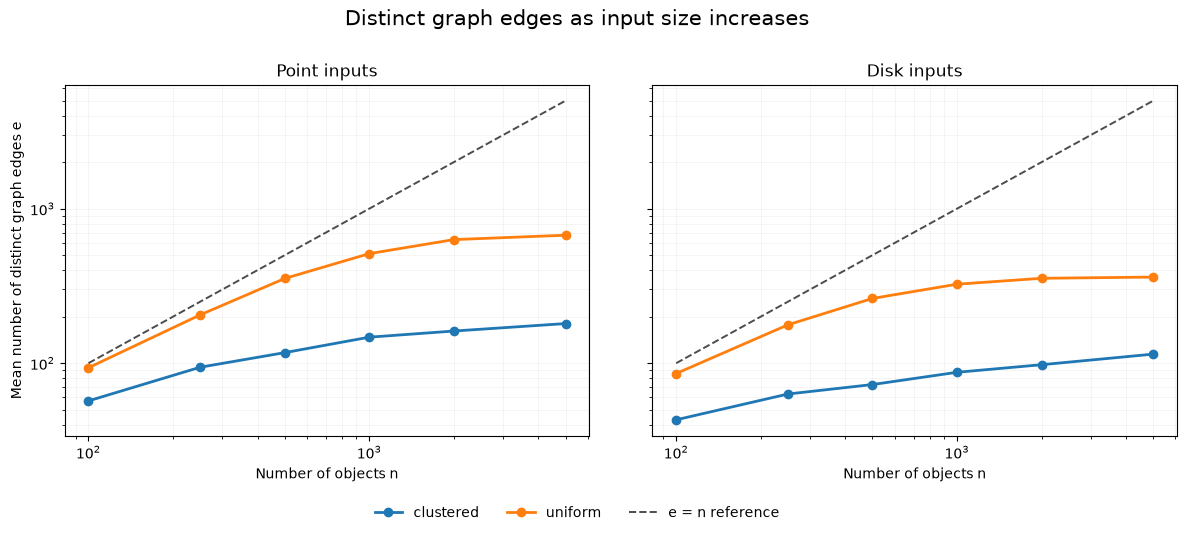

Saved Figure 4.5 to: /Users/a11/Desktop/kOLC_dissertation_project/kolc_experiment_results/figure_4_5_graph_edges.png


In [56]:
from pathlib import Path
import csv

summary_path = Path(
    "kolc_experiment_results/runtime_summary.csv"
)

figure_path = Path(
    "kolc_experiment_results/"
    "figure_4_5_graph_edges.png"
)

records = []

with summary_path.open(
    newline="",
    encoding="utf-8"
) as handle:
    for row in csv.DictReader(handle):
        records.append(
            {
                "object_type": row["object_type"],
                "distribution": row["distribution"],
                "n": int(row["n"]),
                "mean_graph_edges": float(
                    row["mean_graph_edges"]
                )
            }
        )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.4),
    sharex=True,
    sharey=True
)

colours = {
    "clustered": "tab:blue",
    "uniform": "tab:orange"
}

for ax, object_type, title in zip(
    axes,
    ["point", "disk"],
    ["Point inputs", "Disk inputs"]
):
    subset = [
        row for row in records
        if row["object_type"] == object_type
    ]

    for distribution in ["clustered", "uniform"]:
        group = sorted(
            [
                row for row in subset
                if row["distribution"] == distribution
            ],
            key=lambda row: row["n"]
        )

        ax.plot(
            [row["n"] for row in group],
            [row["mean_graph_edges"] for row in group],
            marker="o",
            linewidth=2,
            label=distribution,
            color=colours[distribution]
        )

    n_values = sorted(
        {row["n"] for row in subset}
    )

    ax.plot(
        n_values,
        n_values,
        linestyle="--",
        linewidth=1.4,
        color="black",
        alpha=0.70,
        label="e = n reference"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Number of objects n")

    ax.grid(
        True,
        which="both",
        alpha=0.18
    )

axes[0].set_ylabel(
    "Mean number of distinct graph edges e"
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Distinct graph edges as input size increases",
    fontsize=15
)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.84,
    bottom=0.19,
    wspace=0.12
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved Figure 4.5 to: "
    f"{figure_path.resolve()}"
)

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch


# ============================================================
# 1. Representative input used in Chapter 4
# ============================================================

example_centres = np.array([
    [1, 2],
    [2, 5],
    [4, 3],
    [6, 7],
    [8, 1],
    [10, 4],
    [12, 8],
    [15, 3],
    [16, 9],
    [10, 19]
], dtype=float)


# Run the point and disk comparisons.
# The algorithm functions must already have been defined earlier
# in the notebook.

point_approximation, point_exact, point_ratio = compare_point_algorithms(
    example_centres,
    k=3,
    r=2.0,
    verbose=False
)

disk_approximation, disk_exact, disk_ratio = compare_disk_algorithms(
    example_centres,
    k=3,
    r=1.0,
    rho=0.8,
    verbose=False
)


# ============================================================
# 2. Plotting configuration
# ============================================================

VERTICAL_COLOUR = "#1f77b4"
HORIZONTAL_COLOUR = "#ff7f0e"
BAND_ALPHA = 0.11

point_r = float(point_approximation["r"])
disk_rho = float(disk_approximation["disk_radius"])
disk_R = float(disk_approximation["effective_radius"])

# Use the same coordinate limits in all four panels.
margin = max(point_r, disk_R, disk_rho) + 1.5

x_limits = (
    float(example_centres[:, 0].min() - margin),
    float(example_centres[:, 0].max() + margin)
)

y_limits = (
    float(example_centres[:, 1].min() - margin),
    float(example_centres[:, 1].max() + margin)
)


def draw_solution(
    ax,
    centres,
    vertical_lines,
    horizontal_lines,
    coverage_radius,
    title,
    parameter_text,
    object_prefix,
    disk_radius=None
):
    """
    Draw one point or equal-radius disk solution.

    coverage_radius:
        r for point inputs;
        R = r + rho for disk inputs.
    """

    # Vertical selected lines and coverage bands
    for x_coordinate in vertical_lines:
        ax.axvspan(
            x_coordinate - coverage_radius,
            x_coordinate + coverage_radius,
            color=VERTICAL_COLOUR,
            alpha=BAND_ALPHA,
            zorder=0
        )

        ax.axvline(
            x_coordinate,
            color=VERTICAL_COLOUR,
            linewidth=2.2,
            zorder=2
        )

    # Horizontal selected lines and coverage bands
    for y_coordinate in horizontal_lines:
        ax.axhspan(
            y_coordinate - coverage_radius,
            y_coordinate + coverage_radius,
            color=HORIZONTAL_COLOUR,
            alpha=BAND_ALPHA,
            zorder=0
        )

        ax.axhline(
            y_coordinate,
            color=HORIZONTAL_COLOUR,
            linewidth=2.2,
            zorder=2
        )

    # Input objects
    for index, (x_coordinate, y_coordinate) in enumerate(
        centres,
        start=1
    ):
        # Draw disk boundary only for disk inputs
        if disk_radius is not None:
            disk = Circle(
                (x_coordinate, y_coordinate),
                disk_radius,
                fill=False,
                edgecolor="black",
                linewidth=1.15,
                zorder=4
            )
            ax.add_patch(disk)

        # Point or disk centre
        ax.scatter(
            x_coordinate,
            y_coordinate,
            s=24,
            color="black",
            zorder=5
        )

        ax.annotate(
            f"{object_prefix}{index}",
            (x_coordinate, y_coordinate),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            zorder=6
        )

    # Shared formatting
    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("x-coordinate")
    ax.set_ylabel("y-coordinate")
    ax.set_title(
        title,
        fontsize=12,
        fontweight="semibold",
        pad=8
    )

    ax.grid(
        True,
        alpha=0.18,
        linewidth=0.6
    )

    ax.tick_params(labelsize=8.5)

    # Parameter box
    ax.text(
        0.02,
        0.975,
        parameter_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=8.5,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#b8b8b8",
            "alpha": 0.90
        }
    )


# ============================================================
# 3. Create the four-panel figure
# ============================================================

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "axes.spines.top": True,
    "axes.spines.right": True
}):
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(12.4, 11)
    )

    # (a) Point Algorithm 1
    draw_solution(
        ax=axes[0, 0],
        centres=example_centres,
        vertical_lines=point_approximation["selected_v_lines"],
        horizontal_lines=point_approximation["selected_h_lines"],
        coverage_radius=point_r,
        title=(
            f"(a) Point - Algorithm 1 "
            f"({point_approximation['selected_line_count']} lines)"
        ),
        parameter_text=r"$n=10,\ k=3,\ r=2.0$",
        object_prefix="P"
    )

    # (b) Exact point solution
    draw_solution(
        ax=axes[0, 1],
        centres=example_centres,
        vertical_lines=point_exact["selected_v_lines"],
        horizontal_lines=point_exact["selected_h_lines"],
        coverage_radius=point_r,
        title=(
            f"(b) Point - Exact solution "
            f"({point_exact['selected_line_count']} lines)"
        ),
        parameter_text=r"$n=10,\ k=3,\ r=2.0$",
        object_prefix="P"
    )

    # (c) Disk Algorithm 1
    draw_solution(
        ax=axes[1, 0],
        centres=example_centres,
        vertical_lines=disk_approximation["selected_v_lines"],
        horizontal_lines=disk_approximation["selected_h_lines"],
        coverage_radius=disk_R,
        title=(
            f"(c) Equal-radius disks - Algorithm 1 "
            f"({disk_approximation['selected_line_count']} lines)"
        ),
        parameter_text=(
            r"$n=10,\ k=3,\ r=1.0,\ "
            r"\rho=0.8,\ R=1.8$"
        ),
        object_prefix="D",
        disk_radius=disk_rho
    )

    # (d) Exact disk solution
    draw_solution(
        ax=axes[1, 1],
        centres=example_centres,
        vertical_lines=disk_exact["selected_v_lines"],
        horizontal_lines=disk_exact["selected_h_lines"],
        coverage_radius=disk_R,
        title=(
            f"(d) Equal-radius disks - Exact solution "
            f"({disk_exact['selected_line_count']} lines)"
        ),
        parameter_text=(
            r"$n=10,\ k=3,\ r=1.0,\ "
            r"\rho=0.8,\ R=1.8$"
        ),
        object_prefix="D",
        disk_radius=disk_rho
    )

    # Shared legend
    legend_items = [
        Line2D(
            [0], [0],
            color=VERTICAL_COLOUR,
            linewidth=2.2,
            label="Selected vertical line"
        ),
        Line2D(
            [0], [0],
            color=HORIZONTAL_COLOUR,
            linewidth=2.2,
            label="Selected horizontal line"
        ),
        Patch(
            facecolor="#bcd7ea",
            edgecolor="none",
            alpha=0.45,
            label="Centre-coverage band"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="black",
            linewidth=0,
            markersize=4.5,
            label="Point / disk centre"
        ),
        Patch(
            facecolor="none",
            edgecolor="black",
            label="Disk boundary"
        )
    ]

    figure.legend(
        handles=legend_items,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.012),
        ncol=5,
        frameon=False,
        fontsize=9
    )

    figure.tight_layout(
        rect=[0, 0.065, 1, 1]
    )

    # ========================================================
    # 4. Export
    # ========================================================

    output_directory = Path("kolc_experiment_results")
    output_directory.mkdir(parents=True, exist_ok=True)
    png_path = output_directory / "figure_4_1_representative_solutions.png"
    pdf_path = output_directory / "figure_4_1_representative_solutions.pdf"

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    print("PNG saved to:", png_path.resolve())
    print("PDF saved to:", pdf_path.resolve())
    print("Point ratio:", point_ratio)
    print("Disk ratio:", disk_ratio)